<a href="https://colab.research.google.com/github/EliotAmado/Data-Science-Mini-Projects/blob/main/Marketing_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
df_food = pd.read_csv('/content/drive/MyDrive/Data/ifood_df.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_food

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014.0,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245.0,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0


Data Cleaning

In [ ]:
df_food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [ ]:
df_food.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [ ]:
df_food.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [ ]:
df_food.duplicated().sum()
# Check for duplicates
duplicates = df_food[df_food.duplicated()]

# Display the duplicates
print(f"Number of duplicate rows: {len(duplicates)}")
print("Duplicate rows:")
print(duplicates)

Number of duplicate rows: 184
Duplicate rows:
       Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
77    38620.0        0         0       56       112         17   
167   78497.0        0         0       44       207         26   
267   51369.0        0         1       84       297          7   
268   37760.0        0         0       20        84          5   
346   37717.0        1         0       31         9          0   
...       ...      ...       ...      ...       ...        ...   
2185  22775.0        1         0       40         5          1   
2188  75777.0        0         0       12       712         26   
2192  58554.0        1         1       55       368         24   
2199  34421.0        1         0       81         3          3   
2201  64014.0        2         1       56       406          0   

      MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  ...  \
77                 44               34                22            89  ...   
167

In [ ]:
#Dropping Duplciates
#df_food.drop_duplicates(inplace=True)
#df_food

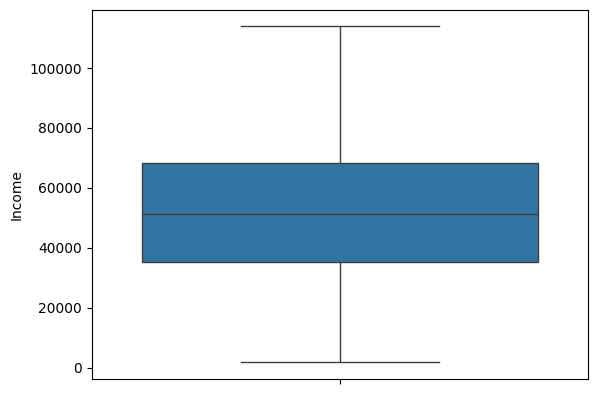

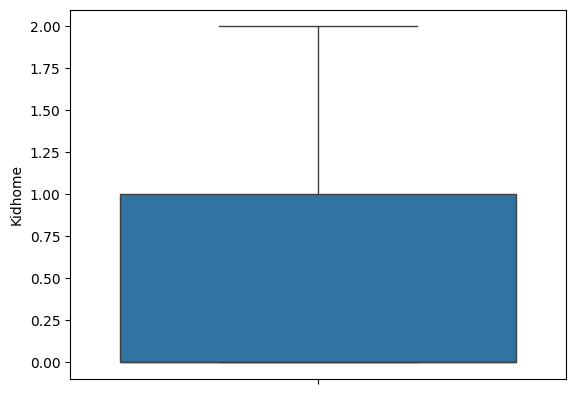

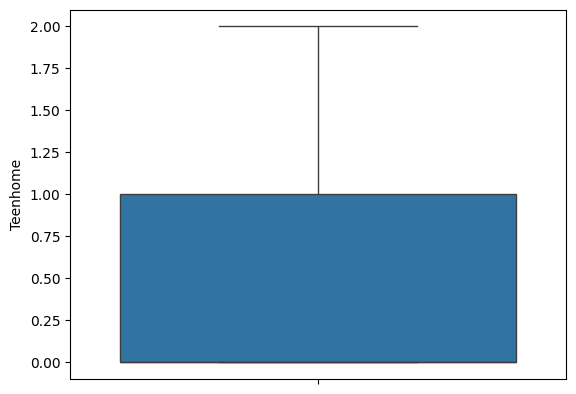

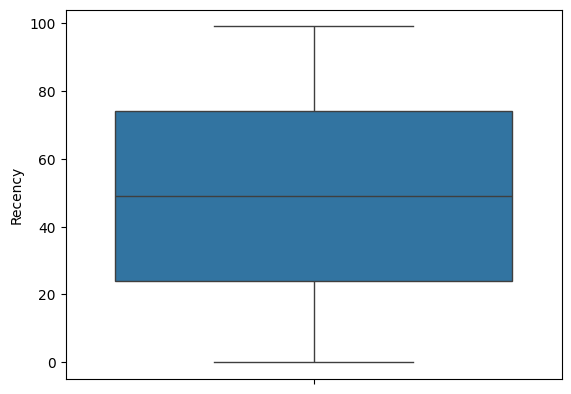

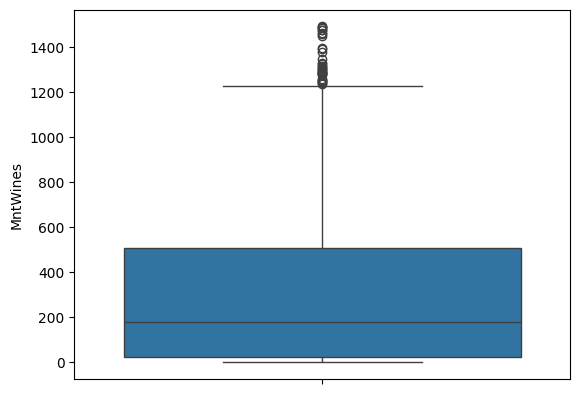

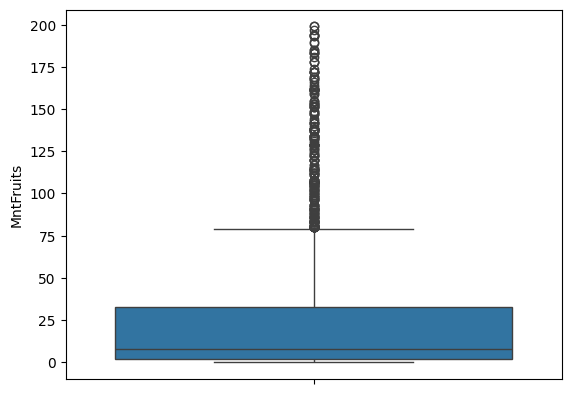

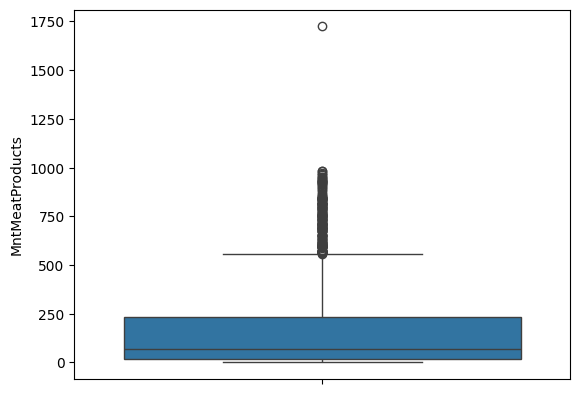

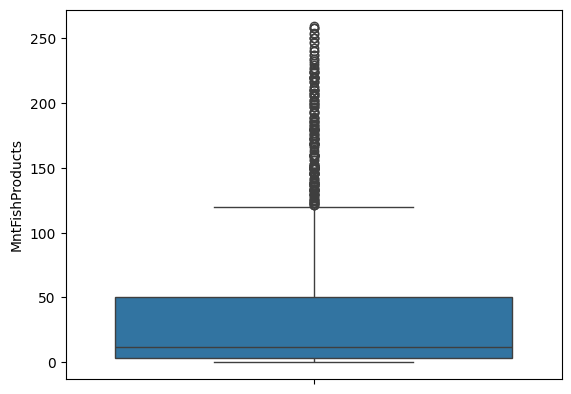

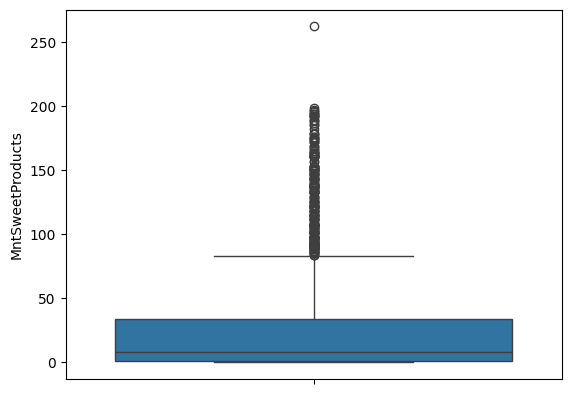

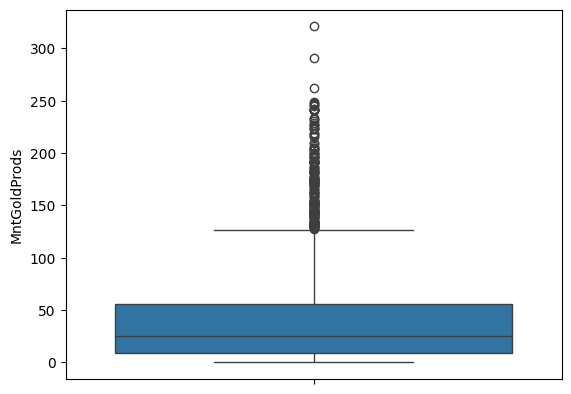

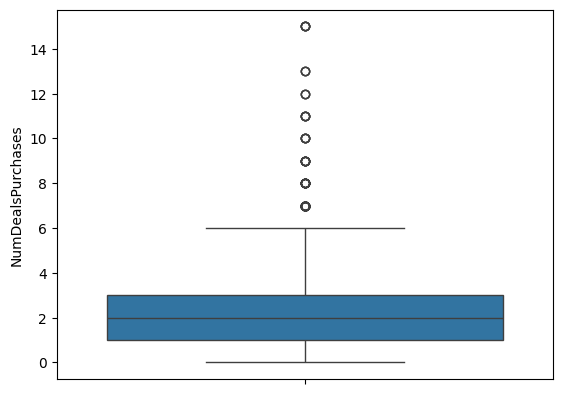

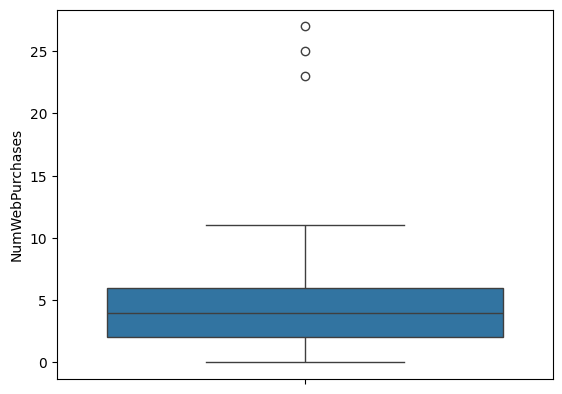

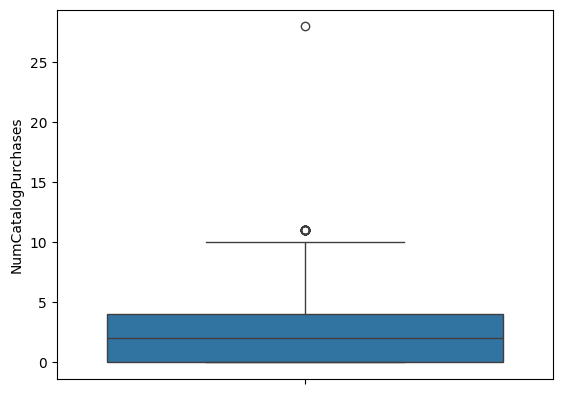

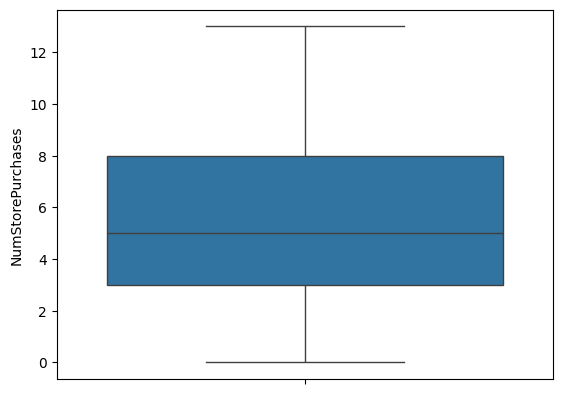

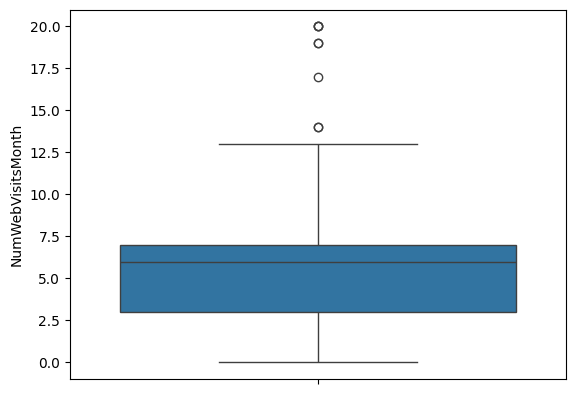

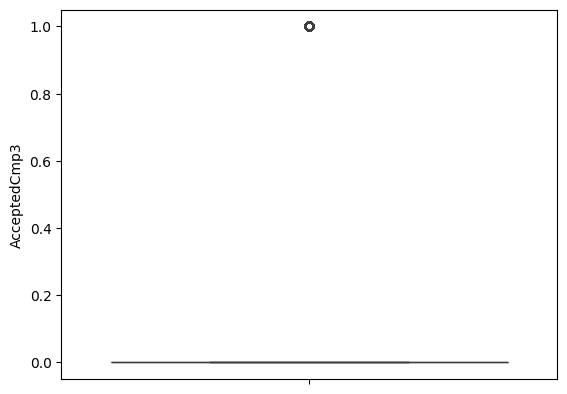

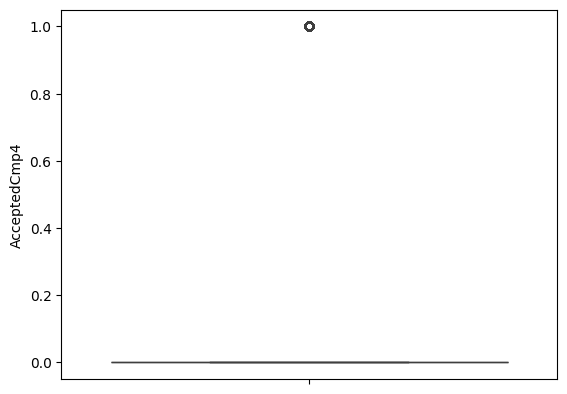

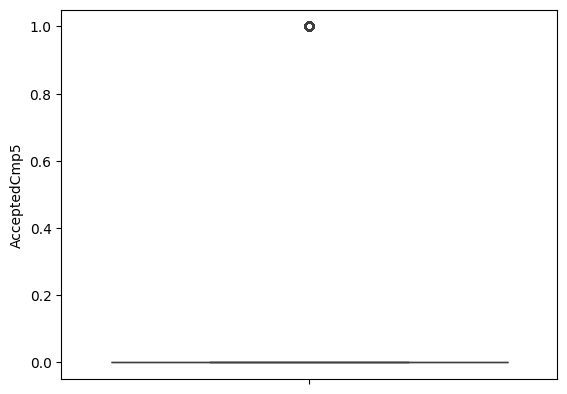

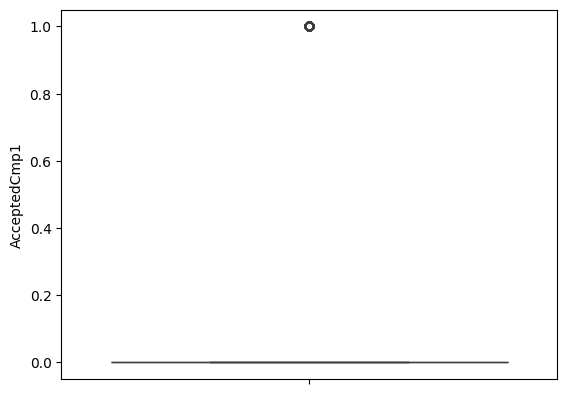

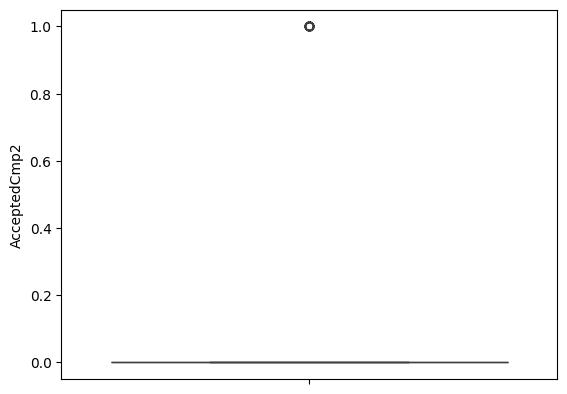

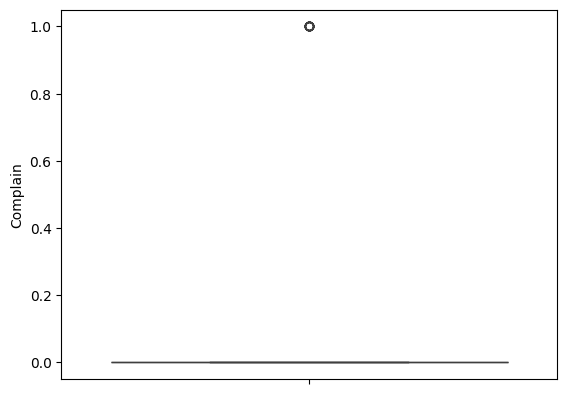

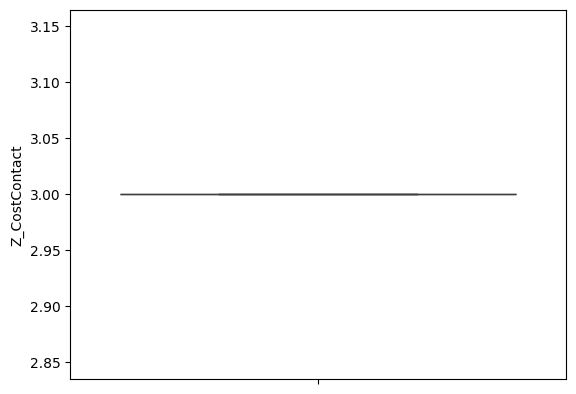

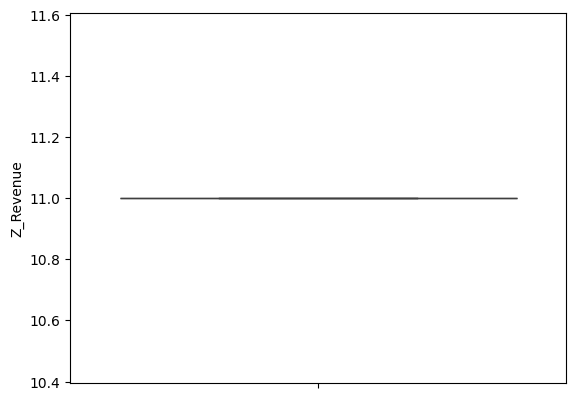

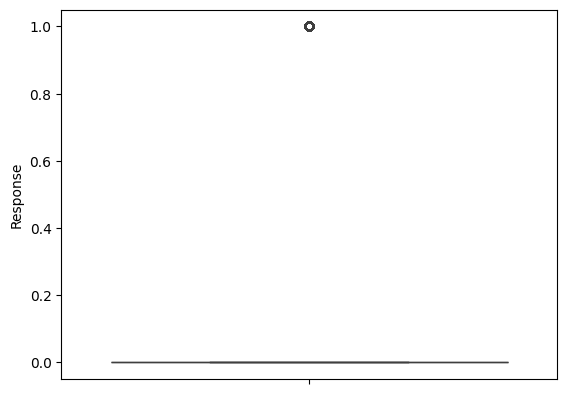

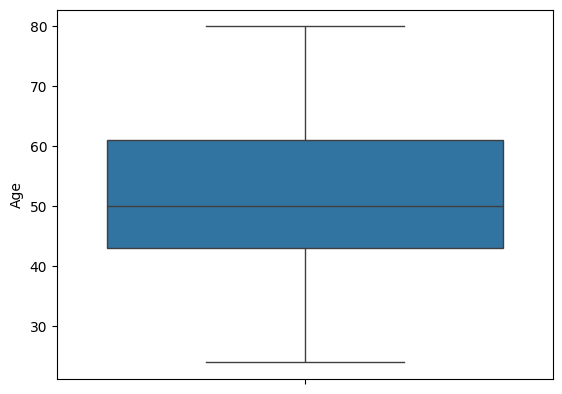

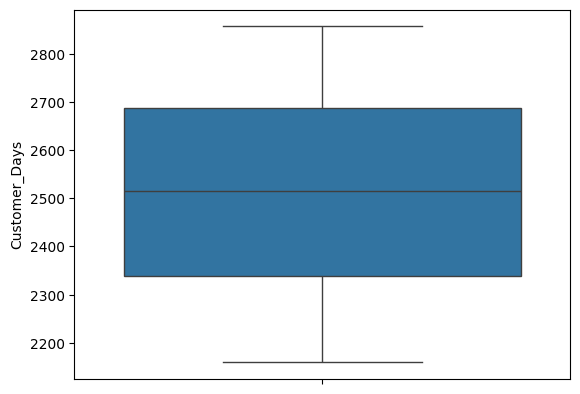

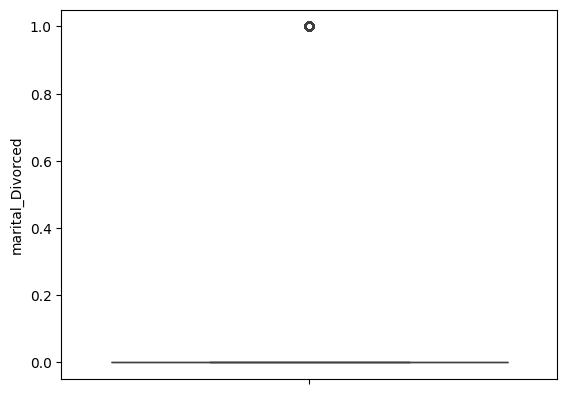

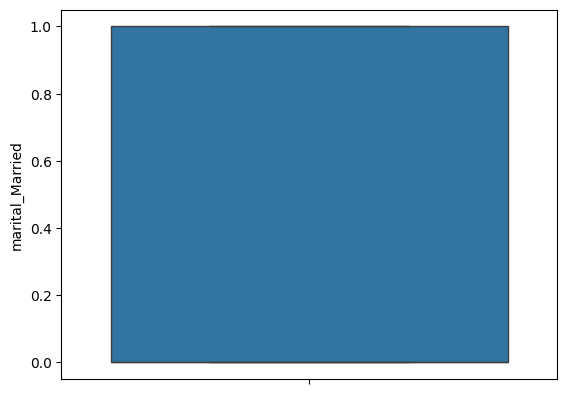

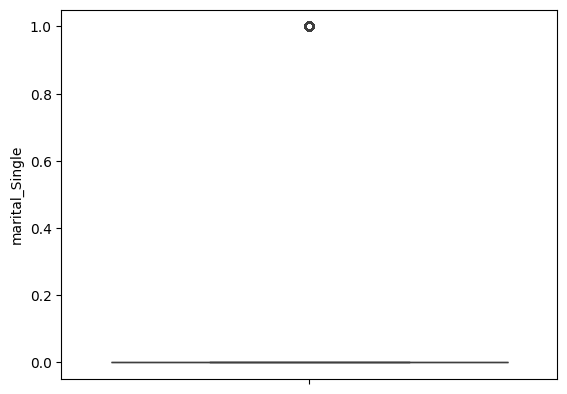

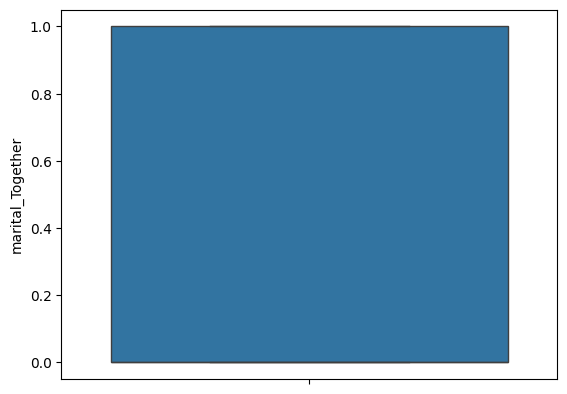

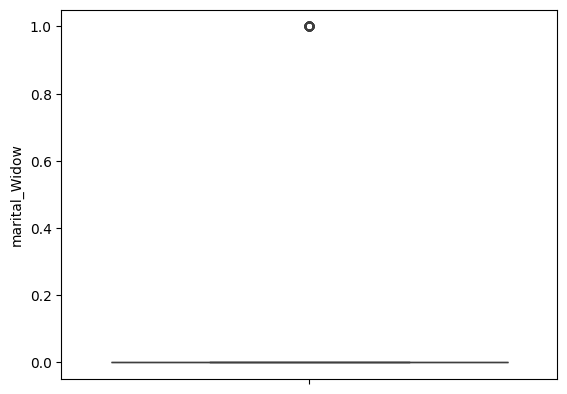

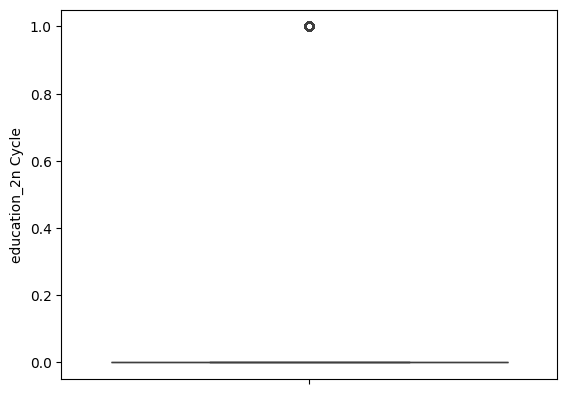

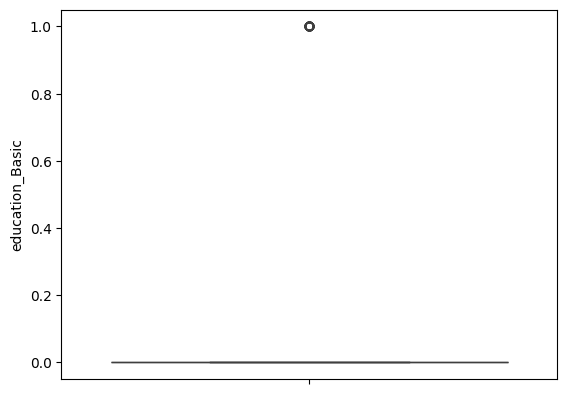

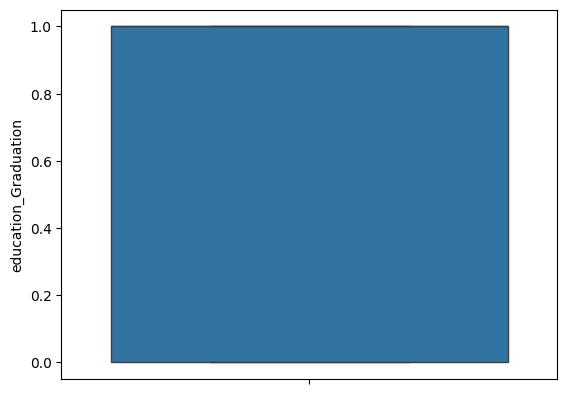

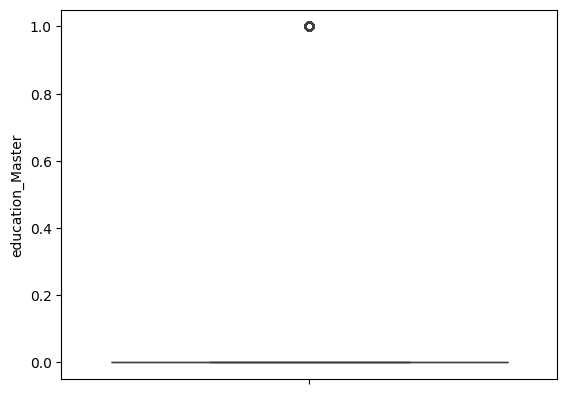

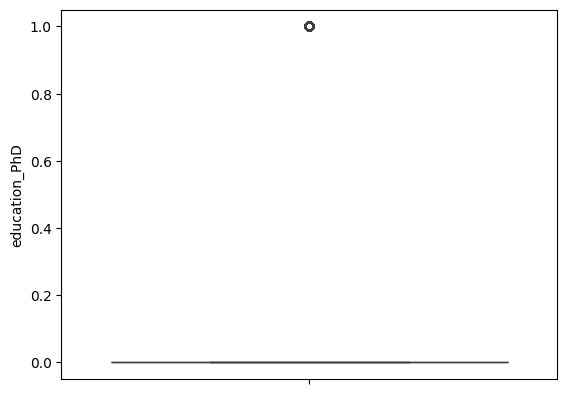

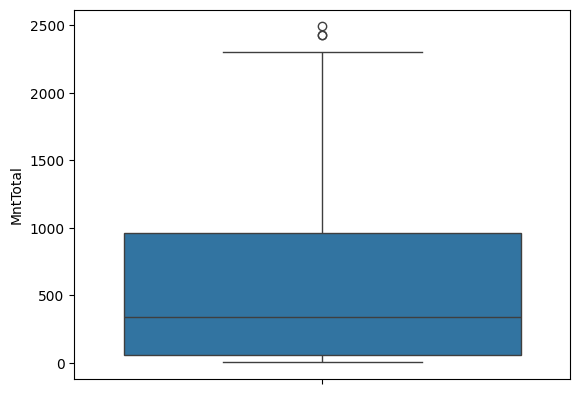

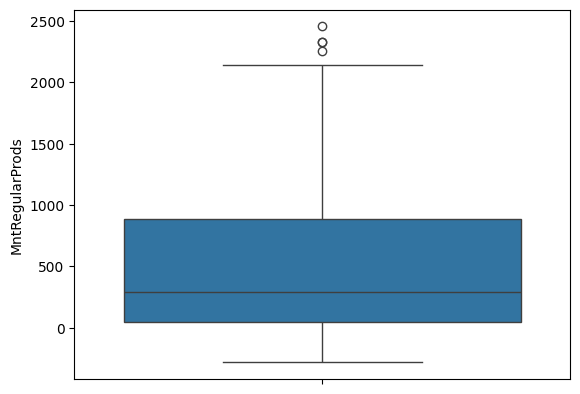

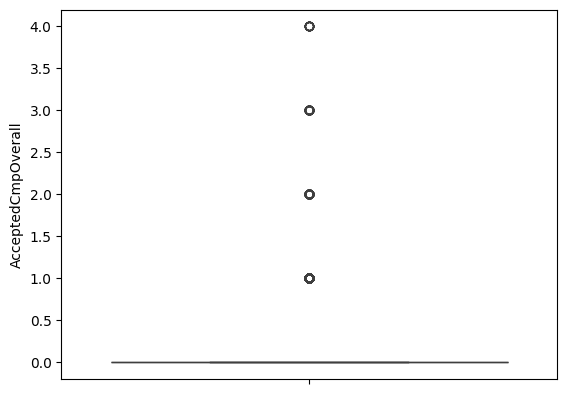

In [ ]:
# Handling Outliers
columnNames = list(df_food.columns)
for i in range(39):
  column_name = columnNames[i]
  sns.boxplot(df_food[column_name])
  plt.show()

# Based on the results, we can proceed, even though there are outliers in some features because these outliers  are not condradictoray/excessively unique to our dataset that deals with individual customers and their purchases

Initial summary of customer demographics

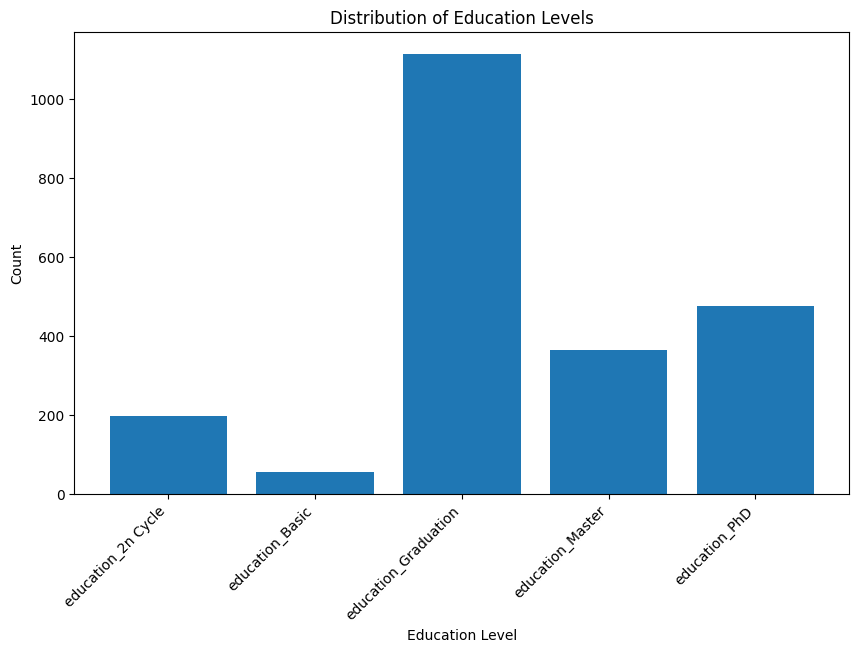

In [ ]:
# Summary of Customer Demographics

# Distribution of Education Levels
# Calculate the sum of each education level column
education_counts = df_food[['education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD']].sum()

# Create a bar chart
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(education_counts.index, education_counts.values)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Levels')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

count    2205.000000
mean       51.095692
std        11.705801
min        24.000000
25%        43.000000
50%        50.000000
75%        61.000000
max        80.000000
Name: Age, dtype: float64


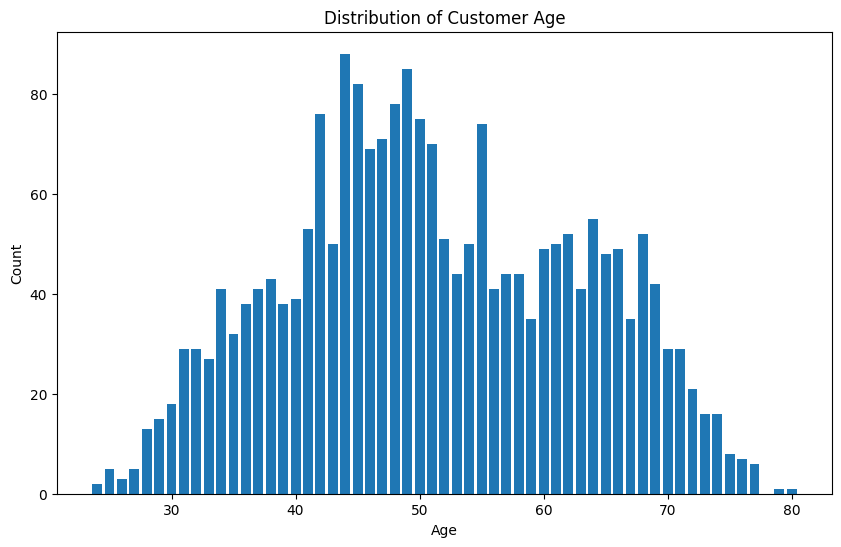

In [ ]:
# Distribution of Customer's Age
age_counts = df_food['Age'].value_counts()

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(age_counts.index, age_counts.values)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Customer Age')

print(df_food['Age'].describe())

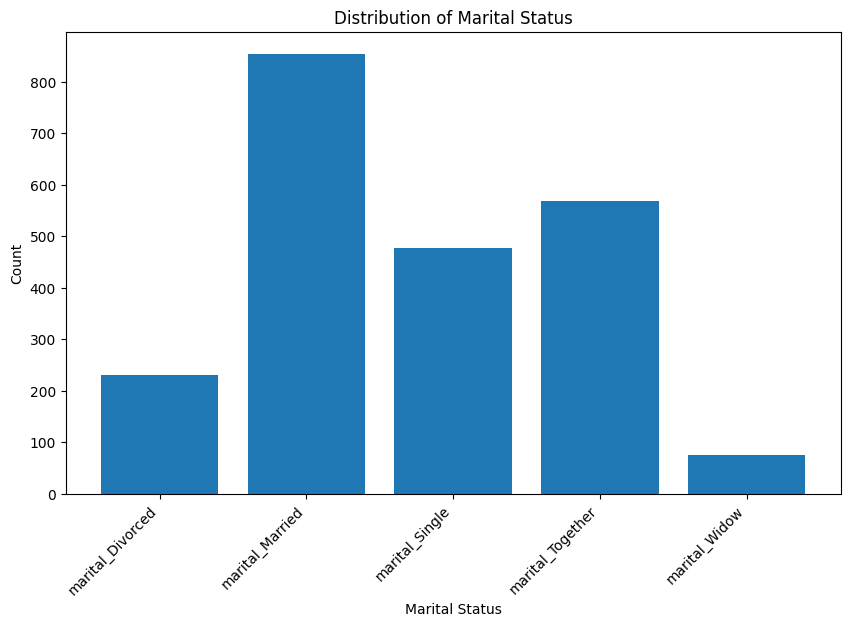

In [ ]:
# Distribution of Martial Status
Marital_counts = df_food[['marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow']].sum()

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(Marital_counts.index, Marital_counts.values)
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.title('Distribution of Marital Status')
plt.xticks(rotation=45, ha='right')
plt.show()


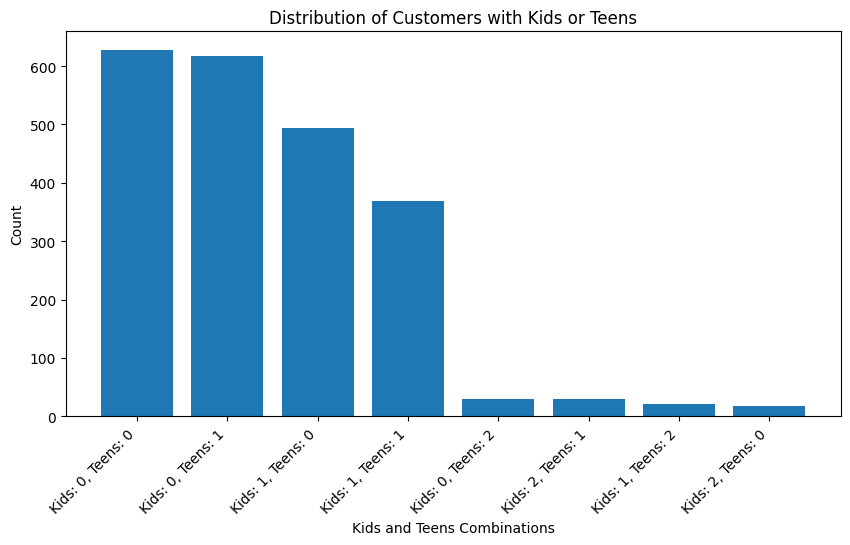

In [ ]:
# Distibution of Customers who have kids or teens
kids_counts = df_food[['Kidhome', 'Teenhome']].value_counts()

# Flatten the multi-index into strings for better plotting
kids_counts.index = [f"Kids: {k}, Teens: {t}" for k, t in kids_counts.index]

# Create a bar chart
plt.figure(figsize=(10, 5))  # Proper figure size
plt.bar(kids_counts.index, kids_counts.values)
plt.xlabel('Kids and Teens Combinations')
plt.ylabel('Count')
plt.title('Distribution of Customers with Kids or Teens')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for clarity
plt.show()


I:nitial summary of campaign performances

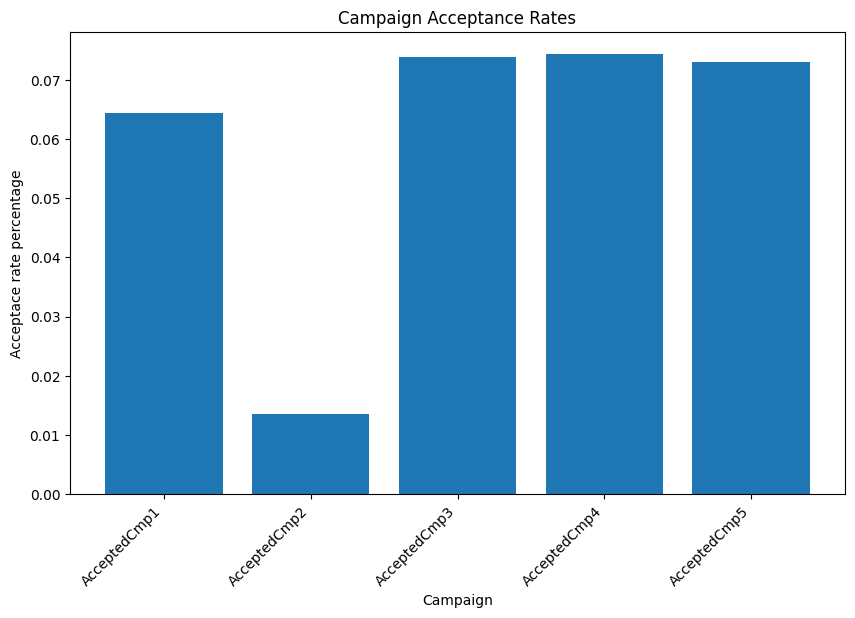

In [ ]:
# Distrubutions of campaign acceptance rates

campaign_counts = df_food[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum()
campaign_rates = campaign_counts / len(df_food)
# Creaste a bar chart
plt.figure(figsize=(10, 6))
plt.bar(campaign_rates.index, campaign_rates.values)
plt.xlabel('Campaign')
plt.ylabel('Acceptace rate percentage')
plt.title('Campaign Acceptance Rates')
plt.xticks(rotation=45, ha='right')
plt.show()

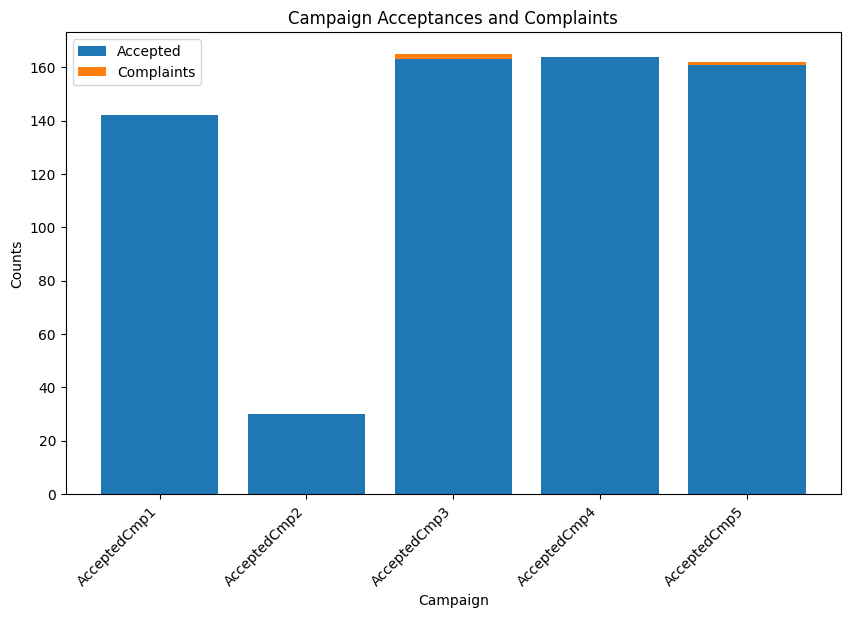

In [ ]:
#complaints by campaign

# Add complaint correlation
complaint_campaigns = df_food[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].multiply(df_food['Complain'], axis=0).sum()

complaints = complaint_campaigns.values
accepted = campaign_counts.values

x = np.arange(len(campaign_counts.index))  # Campaign positions

plt.figure(figsize=(10, 6))
plt.bar(x, accepted, label='Accepted')
plt.bar(x, complaints, label='Complaints', bottom=accepted)
plt.xlabel('Campaign')
plt.ylabel('Counts')
plt.title('Campaign Acceptances and Complaints')
plt.xticks(x, campaign_counts.index, rotation=45, ha='right')
plt.legend()
plt.show()


Initial summary of product preferences and shopping behaviors

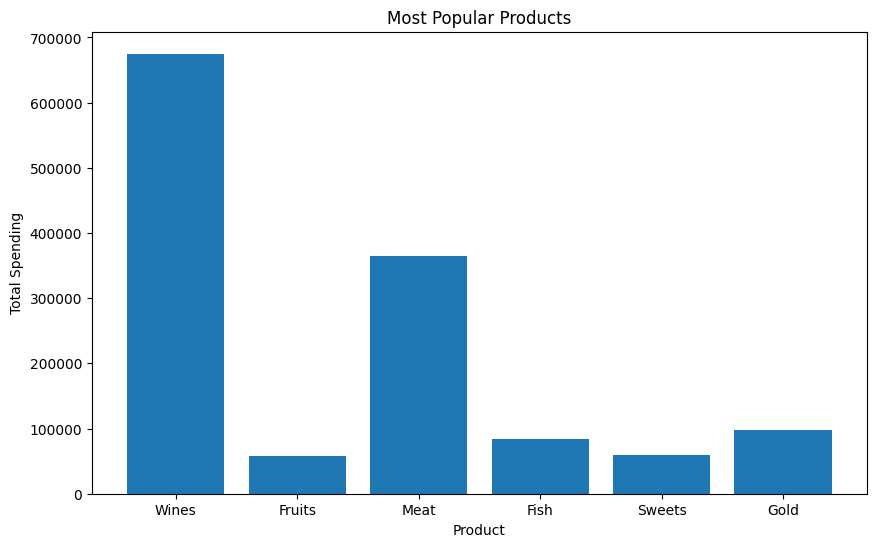

In [ ]:
# Analyze spending habits to identify popular products.
foods_counts = df_food[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()
foods_counts.index = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

#Create a bar chart to find most popular products
plt.figure(figsize=(10, 6))
plt.bar(foods_counts.index, foods_counts.values)
plt.xlabel('Product')
plt.ylabel('Total Spending')
plt.title('Most Popular Products')
plt.show()

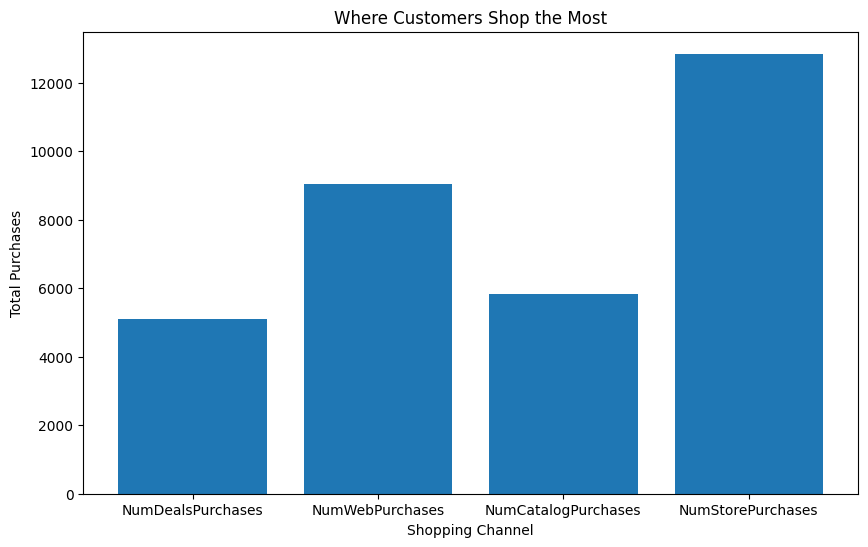

In [ ]:
# Where customers shop the most
shopping_counts = df_food[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum()

# Bar chart to see where customers like to shop the most
plt.figure(figsize=(10, 6))
plt.bar(shopping_counts.index, shopping_counts.values)
plt.xlabel('Shopping Channel')
plt.ylabel('Total Purchases')
plt.title('Where Customers Shop the Most')
plt.show()

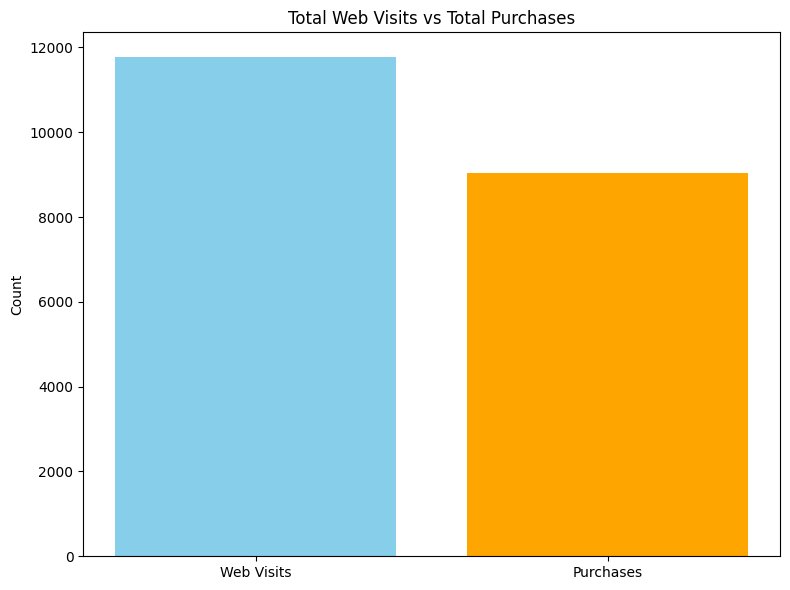

In [ ]:
# Analyze number of web visits a month relative to numwebpurcahses
# Sum the web visits and purchases across all customers
total_web_visits = df_food['NumWebVisitsMonth'].sum()
total_purchases = df_food['NumWebPurchases'].sum()

# Bar chart setup
labels = ['Web Visits', 'Purchases']
values = [total_web_visits, total_purchases]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars
ax.bar(labels, values, color=['skyblue', 'orange'])

# Labels, title, and legend
ax.set_ylabel('Count')
ax.set_title('Total Web Visits vs Total Purchases')

# Display the chart
plt.tight_layout()
plt.show()

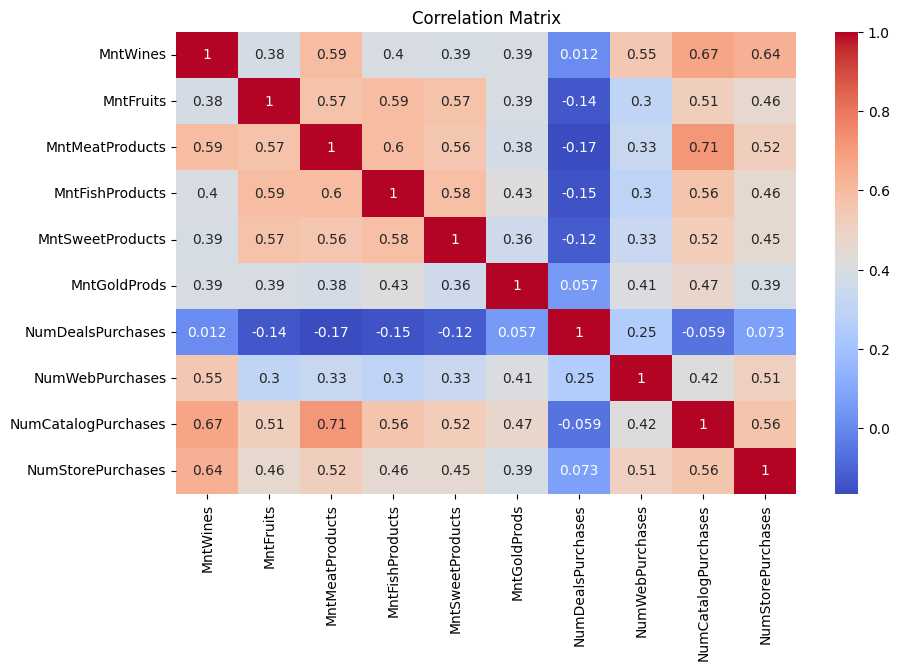

In [ ]:
# Correlation matrix to see correlations between products sold and channels used to buy those products
correlation_matrix = df_food[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].corr()

import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap visualization
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#

Customer Segmentation by Spending

Text(0.5, 1.0, 'Distribution of Spending Categories')

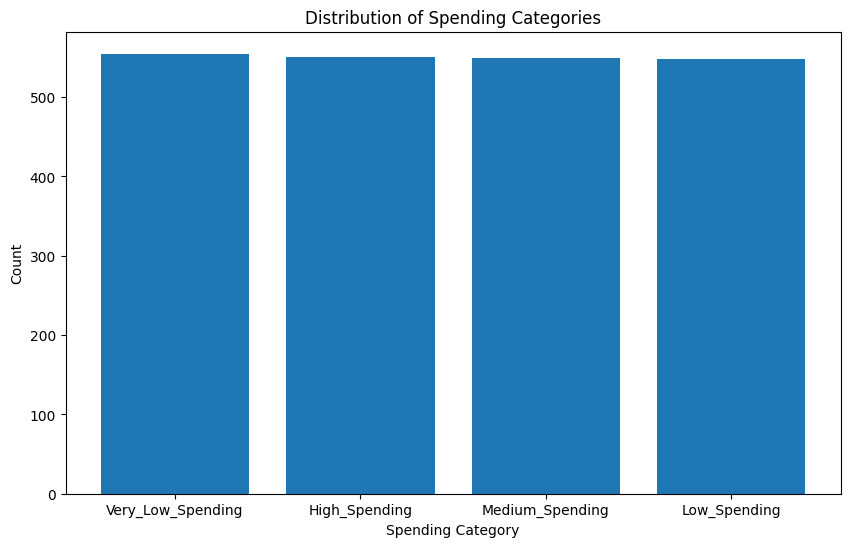

In [ ]:
# Adding up customer purcahses to bin customers into either low, medium, or, highspending customers.
Bins = [5, 69, 397, 1047, 2525] # Used df_food['Spending Total'].describe() to find spending quartiles then use them as bins to find high spending customers
Labels = ['Very_Low_Spending', 'Low_Spending', 'Medium_Spending', 'High_Spending']

df_food['Spending Total'] = df_food['MntWines'] + df_food['MntFruits'] + df_food['MntMeatProducts'] + df_food['MntFishProducts'] + df_food['MntSweetProducts'] + df_food['MntGoldProds']

df_food['Spending_Category'] = pd.cut(df_food['Spending Total'], bins=Bins, labels=Labels)
df_food['Spending_Category']

# bar chart
spending_counts = df_food['Spending_Category'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(spending_counts.index, spending_counts.values)
plt.xlabel('Spending Category')
plt.ylabel('Count')
plt.title('Distribution of Spending Categories')

In [ ]:
# Dissecting types of customers a little further
df_food.groupby('Spending_Category')[['Income', 'Age','NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean()


# We can see that our customers are all around 50
# We can also see that the income customers have correlates to how much they spend at the store.
# We can see that All types of customers prefer shopping in stores
# Medium spending customers purcahse more when deals are offered
# High spending customers use catalogs to purchase the most
# And all type of customers shop alot online
# Reccomendations: Offer medium spending customers more deals, high spending customers more catalog offers, and increase online marketing efforts to help customers shop through there too.

<ipython-input-20-ed855fea0984>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_food.groupby('Spending_Category')[['Income', 'Age','NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean()


,Income,Age,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Spending_Category,,,,,,
Very_Low_Spending,30411.491892,47.951351,1.666667,1.394595,0.209009,2.758559
Low_Spending,41029.173358,50.447080,2.684307,3.302920,1.023723,4.027372
Medium_Spending,60472.003636,53.961818,3.120000,6.070909,3.543636,8.001818
High_Spending,74775.408348,52.054446,1.814882,5.660617,5.820327,8.533575


<ipython-input-21-3667ef85222f>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_purchases = df_food.groupby('Spending_Category')[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean()


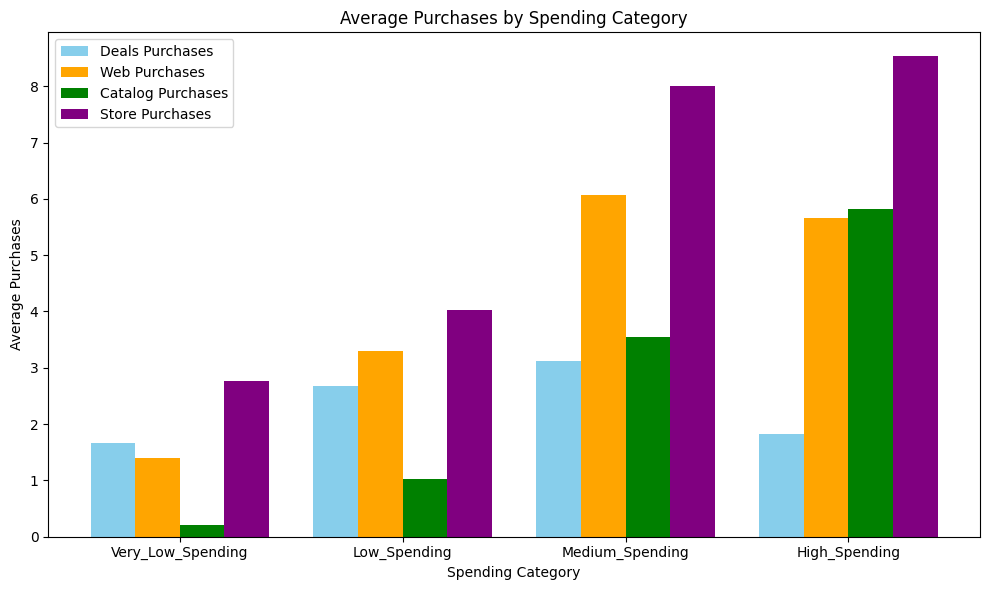

In [ ]:
# Displaying average purchase by spending category

# Calculate the mean for each spending category
avg_purchases = df_food.groupby('Spending_Category')[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean()

# Define the positions for the groups
categories = avg_purchases.index
x = np.arange(len(categories))

# Bar width
width = 0.2

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width*1.5, avg_purchases['NumDealsPurchases'], width, label='Deals Purchases', color='skyblue')
ax.bar(x - width/2, avg_purchases['NumWebPurchases'], width, label='Web Purchases', color='orange')
ax.bar(x + width/2, avg_purchases['NumCatalogPurchases'], width, label='Catalog Purchases', color='green')
ax.bar(x + width*1.5, avg_purchases['NumStorePurchases'], width, label='Store Purchases', color='purple')

# Add labels, title, and legend
ax.set_xlabel('Spending Category')
ax.set_ylabel('Average Purchases')
ax.set_title('Average Purchases by Spending Category')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Display the chart
plt.tight_layout()
plt.show()

In [ ]:
df_food.groupby('Spending_Category')['AcceptedCmpOverall'].sum()

# Customers who spend more, are more likely to accept campaigns. Campaign efforts could be redirected to target these high spending customers

<ipython-input-22-d9ce2cb73d81>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_food.groupby('Spending_Category')['AcceptedCmpOverall'].sum()


,AcceptedCmpOverall
Spending_Category,
Very_Low_Spending,44
Low_Spending,54
Medium_Spending,139
High_Spending,423


<ipython-input-23-18a3bff7682f>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_campAccept = df_food.groupby('Spending_Category')[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].mean()


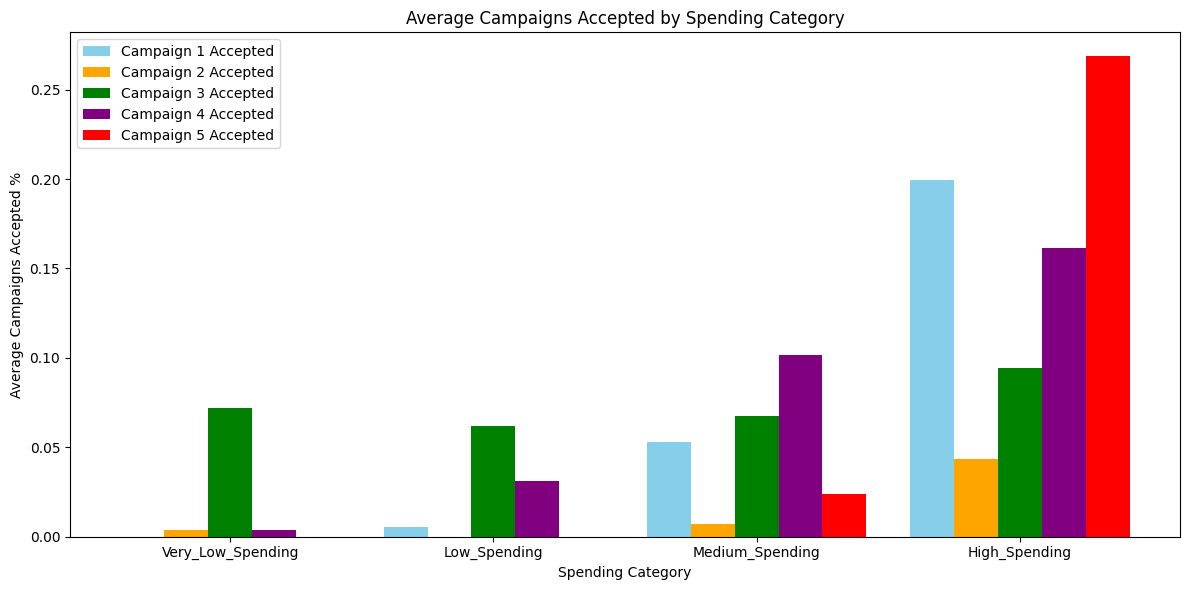

In [ ]:
# Lets dive a little deeper into what which campaigns each spender accepts most

# Calculate the mean for each spending category
avg_campAccept = df_food.groupby('Spending_Category')[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].mean()

# Define the positions for the groups
categories = avg_campAccept.index
x = np.arange(len(categories)) * 1.5  # Add spacing between groups

# Bar width
width = 0.25

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width*2, avg_campAccept['AcceptedCmp1'], width, label='Campaign 1 Accepted', color='skyblue')
ax.bar(x - width, avg_campAccept['AcceptedCmp2'], width, label='Campaign 2 Accepted', color='orange')
ax.bar(x, avg_campAccept['AcceptedCmp3'], width, label='Campaign 3 Accepted', color='green')
ax.bar(x + width, avg_campAccept['AcceptedCmp4'], width, label='Campaign 4 Accepted', color='purple')
ax.bar(x + width*2, avg_campAccept['AcceptedCmp5'], width, label='Campaign 5 Accepted', color='red')

# Add labels, title, and legend
ax.set_xlabel('Spending Category')
ax.set_ylabel('Average Campaigns Accepted %')
ax.set_title('Average Campaigns Accepted by Spending Category')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Display the chart
plt.tight_layout()
plt.show()


In [ ]:
df_food['Recency'].describe()

,Recency
count,2205.000000
mean,49.009070
std,28.932111
min,0.000000
25%,24.000000
50%,49.000000
75%,74.000000
max,99.000000


In [ ]:
# Export df_food to make cool PowerBI graphics
df_food.to_csv('/content/drive/MyDrive/Data/ifood_df_clean.csv', index=False)

Temporal Patterns and Recency

In [ ]:
# Looking into Recency (number of days since the last purchase) to see if we can uncover what features correlate with how often customer shop

#Ordinal Encoding (because there is a hiearchy very_low_spending < low_spending < medium_spending etc..) to see if there a relationship between last purchase, and type of spender
df_food2 = df_food.copy()
mapping = {'Very_Low_Spending': 1, 'Low_Spending': 2, 'Medium_Spending': 3, 'High_Spending': 4 }
df_food2['Spending_Category'] = df_food2['Spending_Category'].map(mapping)
df_food2['Spending_Category']


,Spending_Category
0,4
1,1
2,3
3,1
4,3
...,...
2200,4
2201,3
2202,4
2203,3


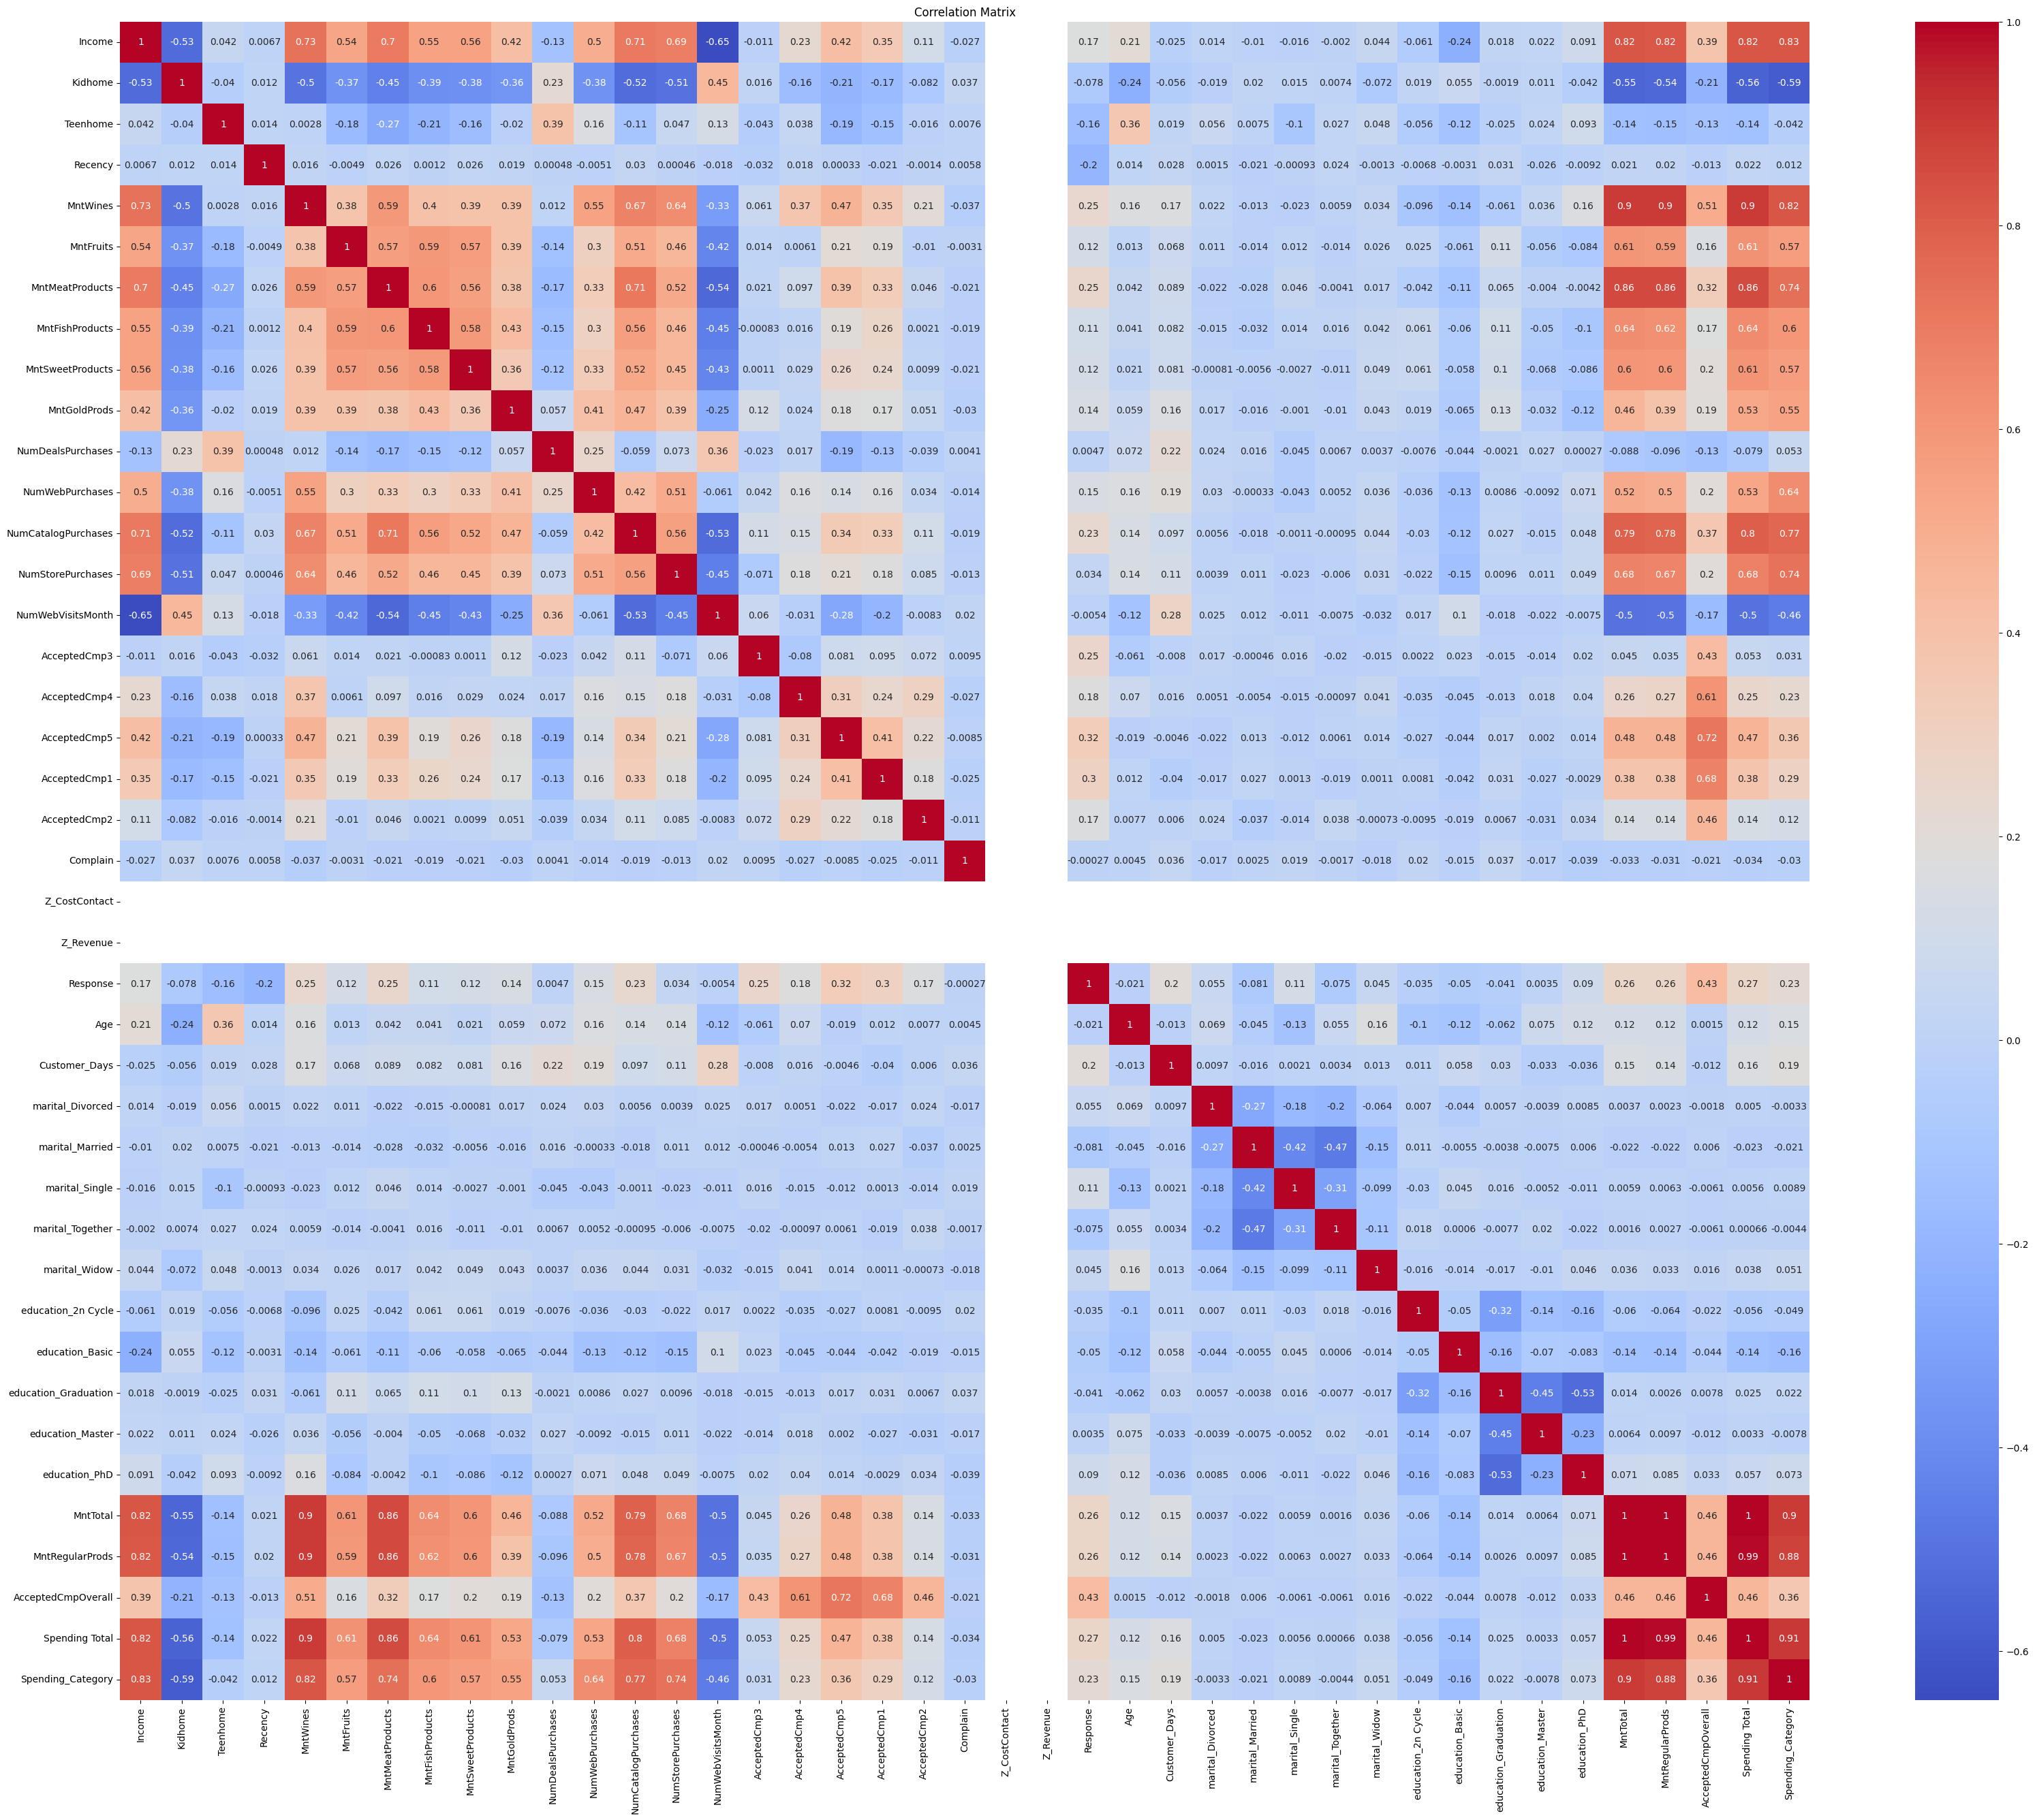

In [ ]:
# Corr matrix to find if any other feature correlates with recency
correlation_matrix = df_food2.corr()

# Heatmap visualization
plt.figure(figsize=(40, 32))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#Outcome: No feature has a linear correlation with variable recency

Customer Segmentation / Clustering

In [ ]:
# Count the number of NaN values in each column
nan_counts = df_food2.isna().sum()

# Show the total number of NaN values in each column
print(nan_counts)


Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [ ]:
# Percentage of NaN values in the 'Spending_Category' column
nan_spending_category_percentage = df_food2['Spending_Category'].isna().mean() * 100

print(f"Percentage of NaN values in 'Spending_Category': {nan_spending_category_percentage}%")

# Since NaN values are low, we can drop them with little to no impact on our analysis

Percentage of NaN values in 'Spending_Category': 0.045351473922902494%


In [ ]:
df_food2 = df_food2.dropna()


In [ ]:
'''

Use techniques like the elbow method or silhouette score to determine the best number of clusters for your data. This can be done before applying the clustering algorithm.
Apply the clustering algorithm:

Once you've determined the optimal number of clusters, apply your chosen clustering algorithm (e.g., KMeans) to group the customers into clusters.
'''

"\n\nUse techniques like the elbow method or silhouette score to determine the best number of clusters for your data. This can be done before applying the clustering algorithm.\nApply the clustering algorithm:\n\nOnce you've determined the optimal number of clusters, apply your chosen clustering algorithm (e.g., KMeans) to group the customers into clusters.\n"

In [ ]:
df_food2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2204 entries, 0 to 2204
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Income                2204 non-null   float64 
 1   Kidhome               2204 non-null   int64   
 2   Teenhome              2204 non-null   int64   
 3   Recency               2204 non-null   int64   
 4   MntWines              2204 non-null   int64   
 5   MntFruits             2204 non-null   int64   
 6   MntMeatProducts       2204 non-null   int64   
 7   MntFishProducts       2204 non-null   int64   
 8   MntSweetProducts      2204 non-null   int64   
 9   MntGoldProds          2204 non-null   int64   
 10  NumDealsPurchases     2204 non-null   int64   
 11  NumWebPurchases       2204 non-null   int64   
 12  NumCatalogPurchases   2204 non-null   int64   
 13  NumStorePurchases     2204 non-null   int64   
 14  NumWebVisitsMonth     2204 non-null   int64   
 15  AcceptedC

In [ ]:
# Droping Categorical-like features to then scale continuous numerical features
df_food3 = df_food2.copy()

df_food3 = df_food3.drop(columns=['marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'Spending_Category'])
df_food3

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,MntTotal,MntRegularProds,AcceptedCmpOverall,Spending Total
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,3,11,1,63,2822,1529,1441,0,1617
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,3,11,0,66,2272,21,15,0,27
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,3,11,0,55,2471,734,692,0,776
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,3,11,0,36,2298,48,43,0,53
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,3,11,0,39,2320,407,392,0,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223.0,0,1,46,709,43,182,42,118,247,...,0,3,11,0,53,2540,1094,847,0,1341
2201,64014.0,2,1,56,406,0,30,0,0,8,...,0,3,11,0,74,2178,436,428,1,444
2202,56981.0,0,0,91,908,48,217,32,12,24,...,0,3,11,0,39,2314,1217,1193,1,1241
2203,69245.0,0,1,8,428,30,214,80,30,61,...,0,3,11,0,64,2315,782,721,0,843


In [ ]:
# Standardization using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_food3)
scaled_df = pd.DataFrame(scaled_data, columns=df_food3.columns)


In [ ]:
# Combining features 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'Spending_Category' with our scaled_df
scaled_df['marital_Divorced'] = df_food2['marital_Divorced']
scaled_df['martial_Married'] = df_food2['marital_Married']
scaled_df['marital_Single'] = df_food2['marital_Single']
scaled_df['marital_Together'] = df_food2['marital_Together']
scaled_df['marital_Widow'] = df_food2['marital_Widow']
scaled_df['education_2n Cycle'] = df_food2['education_2n Cycle']
scaled_df['education_Basic'] = df_food2['education_Basic']
scaled_df['education_Graduation'] = df_food2['education_Graduation']
scaled_df['education_Master'] = df_food2['education_Master']
scaled_df['education_PhD'] = df_food2['education_PhD']
scaled_df['Spending_Category'] = df_food2['Spending_Category']
scaled_df

# Remove categorical columns before applying PCA and clustering
# After performing PCA, you can proceed with clustering (e.g., K-means) on the transformed features.
'''
a. Remove Categorical Columns Before PCA:
If your dataset includes categorical columns that have been one-hot encoded or ordinally encoded, drop them before performing PCA.

b. Apply PCA to Scaled Numerical Data:
Ensure you're applying PCA only to numerical data, not categorical columns.

c. Apply the Elbow Method:
After dimensionality reduction, proceed with the elbow method to choose the optimal number of clusters.

Here’s how your adjusted code would look:
'''

"\na. Remove Categorical Columns Before PCA:\nIf your dataset includes categorical columns that have been one-hot encoded or ordinally encoded, drop them before performing PCA.\n\nb. Apply PCA to Scaled Numerical Data:\nEnsure you're applying PCA only to numerical data, not categorical columns.\n\nc. Apply the Elbow Method:\nAfter dimensionality reduction, proceed with the elbow method to choose the optimal number of clusters.\n\nHere’s how your adjusted code would look:\n"

In [ ]:
# Investigating to see if any of the columns have NaN values we can remove
nan_counts = scaled_df.isna().sum()
print(nan_counts)


Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
MntTotal                0
MntRegularProds         0
AcceptedCmpOverall      0
Spending Total          0
marital_Divorced        1
martial_Married         1
marital_Single          1
marital_Together        1
marital_Widow           1
education_2n Cycle      1
education_Basic         1
education_Graduation    1
education_Ma

In [ ]:
nan_percentage = (scaled_df.isna().sum() / len(scaled_df)) * 100
nan_percentage = nan_percentage[nan_percentage > 0]  # Keep only columns with NaN
print(nan_percentage)

# Since there is only around 4% of NaN values for each column we can remove them, knowing they won't really affect our final clustering model

marital_Divorced        0.045372
martial_Married         0.045372
marital_Single          0.045372
marital_Together        0.045372
marital_Widow           0.045372
education_2n Cycle      0.045372
education_Basic         0.045372
education_Graduation    0.045372
education_Master        0.045372
education_PhD           0.045372
Spending_Category       0.045372
dtype: float64


In [ ]:
# Removing NaN values in feature Spending_Category
scaled_df = scaled_df.dropna()

In [ ]:
scaled_df.dtypes

,0
Income,float64
Kidhome,float64
Teenhome,float64
Recency,float64
MntWines,float64
MntFruits,float64
MntMeatProducts,float64
MntFishProducts,float64
MntSweetProducts,float64
MntGoldProds,float64


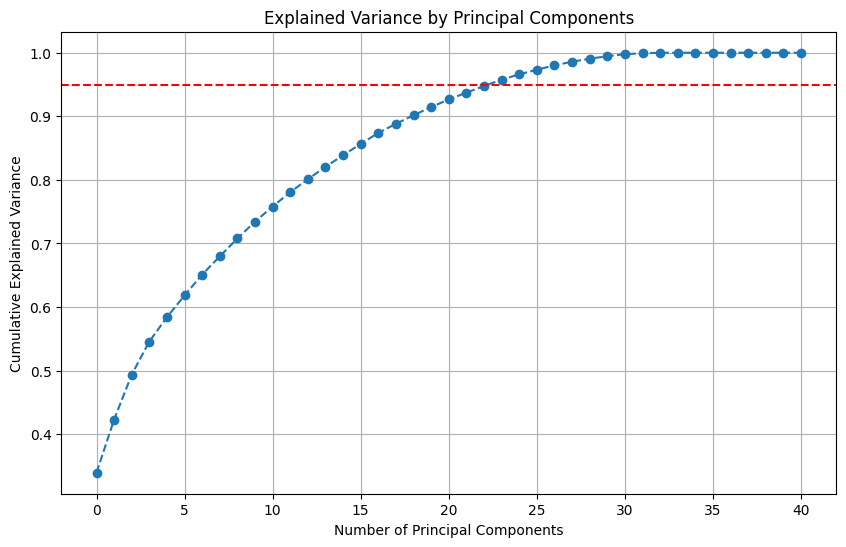

[0.33926562 0.42297482 0.49364324 0.5456675  0.58407114 0.61821851
 0.65108925 0.67964439 0.70784216 0.73429622 0.75800047 0.78070704
 0.80103518 0.82050716 0.83874691 0.85652353 0.87383569 0.88812819
 0.9016523  0.9144626  0.92648296 0.93720287 0.94761017 0.95760487
 0.96593431 0.973259   0.98006428 0.98593848 0.99054565 0.99451682
 0.99777875 0.99908701 1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]
23


In [ ]:
# PCA Dimensionality reduction
from sklearn.decomposition import PCA
pca = PCA()
scaled_df_pca = pca.fit(scaled_df)

# Calculate the cumulative explained variance ratio
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)


# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

# Print the cumulative explained variance for reference
# CHOOSE/DETERMINE the point at which the cumulative explained variance reaches 95% this is a common and practical rule in PCA
print(cumulative_explained_variance)

#Print the point at which the plt.axhline(y=0.95, color='r', linestyle='--')
print(np.argmax(cumulative_explained_variance >= 0.95))


In [ ]:
scaled_df['Spending_Category'] = scaled_df['Spending_Category'].astype(int)

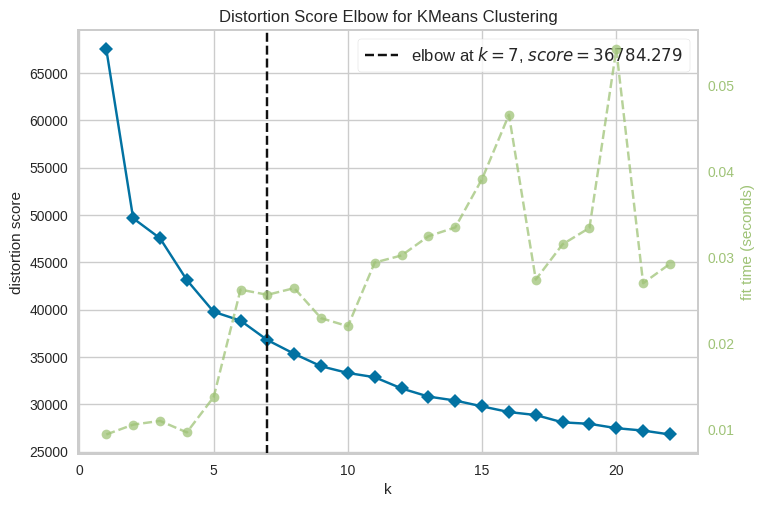

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Elbow Plot:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Ensure you pass a KMeans instance to the Elbow Visualizer
kmeans = KMeans(random_state=1)  # Initialize KMeans without specifying n_clusters
elbow_visualizer = KElbowVisualizer(kmeans, k=(1, 23))  # Define the range of k
elbow_visualizer.fit(scaled_df)
elbow_visualizer.show()